In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.7 s (started: 2026-07-02 22:13:28 +02:00)


In [2]:
!pip install -U topacedo

time: 1.66 s (started: 2026-07-02 22:13:30 +02:00)


In [3]:
# Loading preanalyzed dataset that was processed in the `basic_tutorial` vignette
scarf.fetch_dataset(
    dataset_name="tenx_5K_pbmc_rnaseq", as_zarr=True, save_path="scarf_datasets"
)

time: 27.6 s (started: 2026-07-02 22:13:32 +02:00)


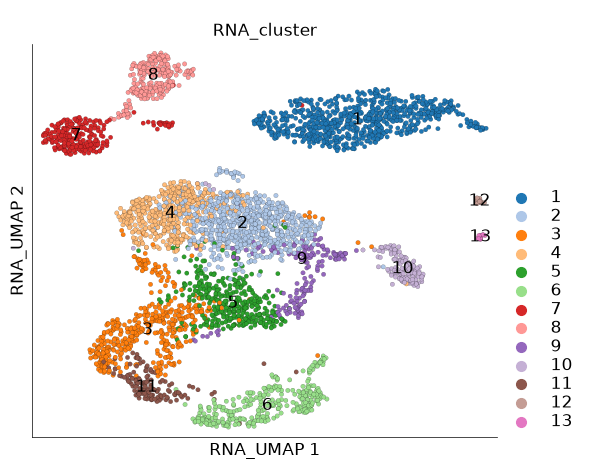

time: 1.55 s (started: 2026-07-02 22:13:59 +02:00)


In [4]:
ds = scarf.DataStore("scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr")

ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_cluster")

In [5]:
ds.run_topacedo_sampler(cluster_key="RNA_cluster", max_sampling_rate=0.1)

Constructing graph from dendrogram:   0%|          | 0/3939 [00:00<?, ?it/s]

Constructing graph from dendrogram: 100%|██████████| 3939/3939 [00:00<00:00, 70500.48it/s]

INFO: 384 cells (9.75%) sub-sampled. Subsample to Seed (165 cells) ratio: 2.327


time: 2.34 s (started: 2026-07-02 22:14:00 +02:00)


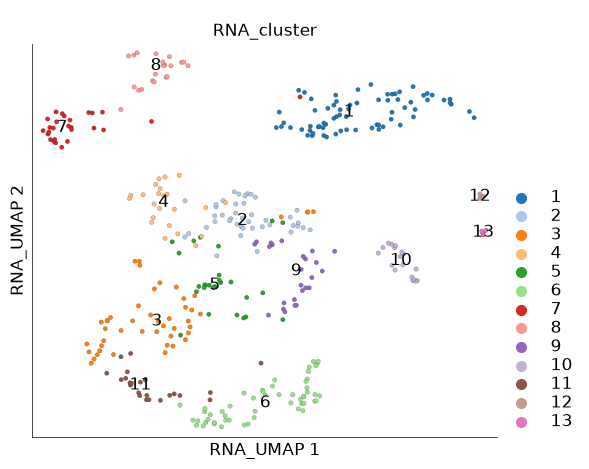

time: 766 ms (started: 2026-07-02 22:14:03 +02:00)


In [6]:
ds.plot_layout(
    layout_key="RNA_UMAP", color_by="RNA_cluster", subselection_key="RNA_sketched"
)

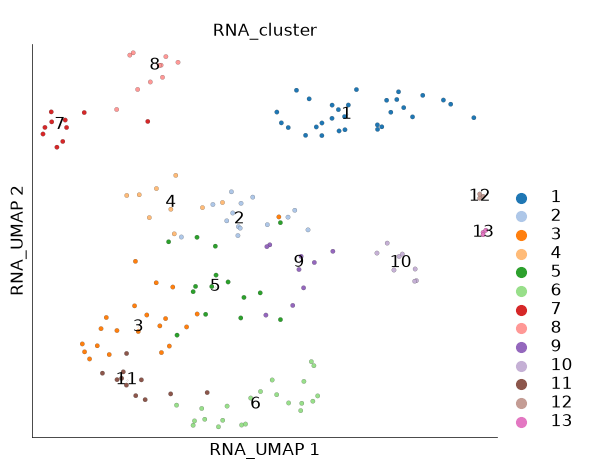

time: 761 ms (started: 2026-07-02 22:14:03 +02:00)


In [7]:
ds.plot_layout(
    layout_key="RNA_UMAP", color_by="RNA_cluster", subselection_key="RNA_sketch_seeds"
)

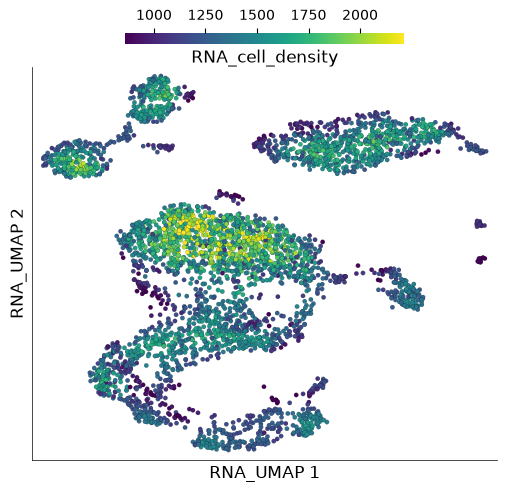

time: 691 ms (started: 2026-07-02 22:14:04 +02:00)


In [8]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_cell_density")

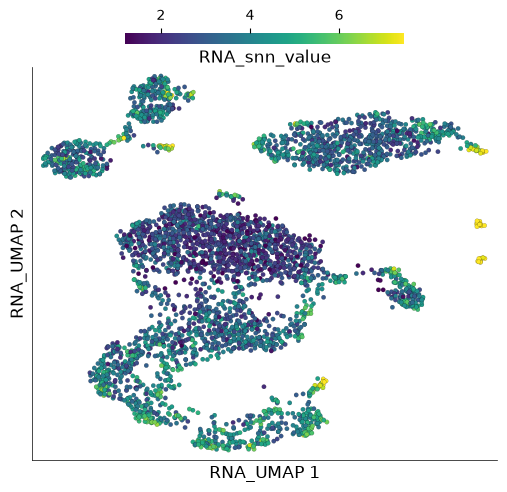

time: 672 ms (started: 2026-07-02 22:14:05 +02:00)


In [9]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_snn_value")

In [10]:
writer = scarf.SubsetZarr(
    zarr_loc="scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr",
    assays=[ds.RNA],
    cell_key="RNA_sketched",
    reset_cell_filter=False,
)
writer.dump()

time: 1.12 s (started: 2026-07-02 22:14:06 +02:00)


In [11]:
ds2 = scarf.DataStore("scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr")

time: 825 ms (started: 2026-07-02 22:14:07 +02:00)


In [12]:
ds2

DataStore has 384 (384) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_cell_density', 
            'RNA_tSNE2', 'RNA_snn_value', 'RNA_tSNE1', 'RNA_sketch_seeds', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_nCounts', 'RNA_cluster', 'RNA_leiden_cluster', 'RNA_UMAP2', 
            'RNA_sketched', 'RNA_UMAP1'
   RNA assay has 8773 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 78 ms (started: 2026-07-02 22:14:08 +02:00)


In [13]:
!pip install anndata

time: 933 ms (started: 2026-07-02 22:14:08 +02:00)


In [14]:
adata = ds2.to_anndata()

time: 951 ms (started: 2026-07-02 22:14:09 +02:00)


In [15]:
adata

AnnData object with n_obs × n_vars = 384 × 33538
    obs: 'I', 'names', 'RNA_tSNE2', 'RNA_percentMito', 'RNA_snn_value', 'RNA_cell_density', 'RNA_tSNE1', 'RNA_sketch_seeds', 'RNA_percentRibo', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_leiden_cluster', 'RNA_cluster', 'RNA_sketched', 'RNA_UMAP2', 'RNA_UMAP1'
    var: 'I', 'names', 'nCells', 'dropOuts'

time: 3.12 ms (started: 2026-07-02 22:14:10 +02:00)
